# Feature 9 — Geopolitical Shock Fingerprinting & Historical Conflict Comparison

### Objective
This feature answers:
> *“Past conflicts mein kya measurable economic/geopolitical shock hua tha, aur current conflict ka shock pattern historically kis type ke conflict se similar hai?”*

The system creates a shock fingerprint for historical conflicts and a current event using measurable indicators such as energy, trade, shipping, commodity and financial/economic signals.

The output is historical pattern comparison, not a guaranteed future-loss prediction.

### Main outputs
- Historical conflict shock fingerprint
- Current event shock fingerprint
- PCA 2D visualization
- K-Means historical conflict clusters
- Closest historical pattern/cluster
- Then vs Now comparison
- Historical observed impact evidence
- Potential impact channels for the current event

### Strict AI/ML syllabus mapping
- **Module 4:** PCA
- **Module 4:** K-Means Clustering
- **Module 4:** Feature Engineering Basics
- **Module 5:** Visualization and interpretation of model output

### Important
No Random Forest, XGBoost, LSTM, ARIMA, Transformer, BERT, Naive Bayes or other out-of-syllabus ML algorithm is used.

The notebook does not invent historical losses or future losses. Historical impact values must come from the supplied/verified dataset.

### Dataset
Expected path:
`data/feature9_geopolitical_shock_fingerprints.csv`

Each row represents one historical conflict/event observation.

#### Required columns
- `conflict`
- `period`
- `energy_shock`
- `trade_disruption`
- `shipping_disruption`
- `commodity_shock`
- `financial_stress`
- `inflation_change`
- `gdp_growth_change`
- `trade_growth_change`
- `oil_price_change`

#### Interpretation
The first five variables form the main shock fingerprint.

The last four economic variables are historical observed impact indicators used for the Then vs Now evidence section.

Do not fabricate these values. Use historical/verified datasets and document the source in the project report.

In [1]:
# Cell 1 — Imports and configuration

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DATA_PATH = "data/feature9_geopolitical_shock_fingerprints.csv"

SHOCK_FEATURES = [
    "energy_shock",
    "trade_disruption",
    "shipping_disruption",
    "commodity_shock",
    "financial_stress"
]

IMPACT_FEATURES = [
    "inflation_change",
    "gdp_growth_change",
    "trade_growth_change",
    "oil_price_change"
]

print("Configuration loaded.")

Configuration loaded.


In [2]:
# Cell 2 — Load dataset

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (22, 11)


,conflict,period,energy_shock,trade_disruption,shipping_disruption,commodity_shock,financial_stress,inflation_change,gdp_growth_change,trade_growth_change,oil_price_change
0,1973 Yom Kippur / Arab Oil Embargo,1973-1974,96.0,68.0,72.0,78.0,84.0,8.4,-3.2,-5.6,285.0
1,1979 Iranian Revolution & Second Oil Shock,1979-1980,92.0,62.0,58.0,74.0,80.0,6.8,-2.4,-4.1,138.0
2,1980 Iran-Iraq Tanker War,1980-1988,86.0,70.0,88.0,60.0,65.0,4.2,-1.5,-3.8,45.0
3,1990 Gulf War (Kuwait Invasion),1990-1991,88.0,74.0,82.0,66.0,72.0,3.6,-1.8,-3.2,94.0
4,1999 Kargil Conflict,1999,28.0,35.0,22.0,25.0,48.0,1.2,-0.4,-1.1,14.0


In [3]:
# Cell 3 — Validate and clean dataset

required_columns = [
    "conflict", "period",
    *SHOCK_FEATURES,
    *IMPACT_FEATURES
]

missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = df.copy()

df["conflict"] = df["conflict"].astype(str).str.strip()
df["period"] = df["period"].astype(str).str.strip()

for col in SHOCK_FEATURES + IMPACT_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

before = len(df)
df = df.dropna(subset=SHOCK_FEATURES).reset_index(drop=True)
after = len(df)

print("Rows before cleaning:", before)
print("Rows after cleaning:", after)
print("Missing values in shock features:")
print(df[SHOCK_FEATURES].isna().sum())

Rows before cleaning: 22
Rows after cleaning: 22
Missing values in shock features:
energy_shock           0
trade_disruption       0
shipping_disruption    0
commodity_shock        0
financial_stress       0
dtype: int64


### Cell 4 — Exploratory analysis
Before applying PCA/K-Means, inspect how the historical shock indicators vary across conflicts.

This is descriptive analysis and visualization, not a separate ML algorithm.

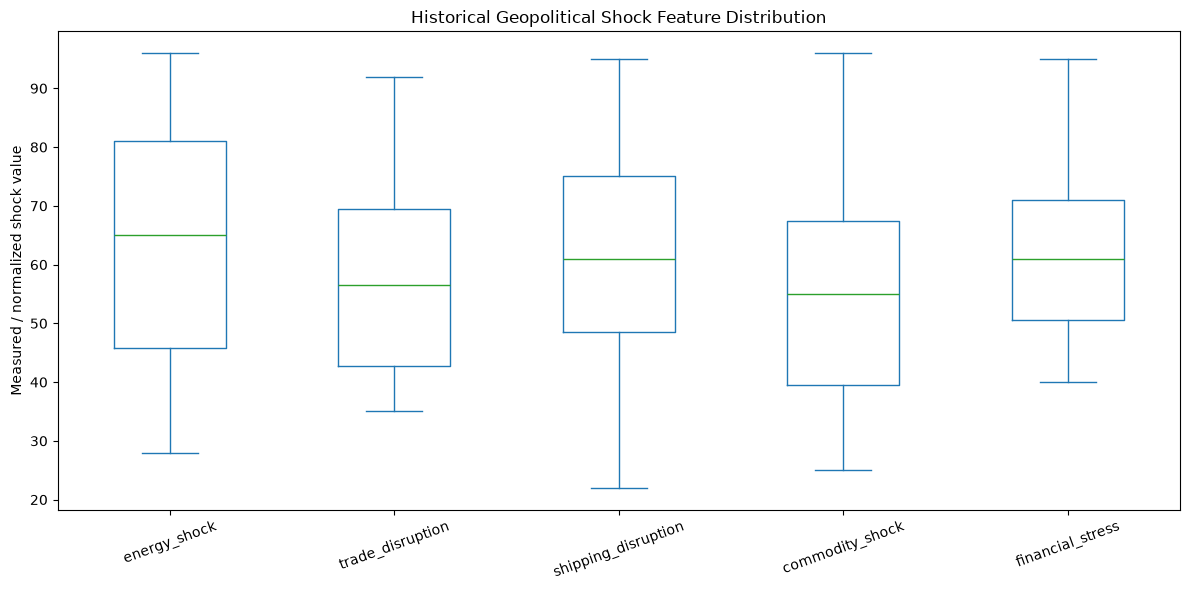

In [4]:
# Cell 4 — Historical shock distribution

df[SHOCK_FEATURES].plot(
    kind="box",
    figsize=(12, 6),
    rot=20
)
plt.title("Historical Geopolitical Shock Feature Distribution")
plt.ylabel("Measured / normalized shock value")
plt.tight_layout()
plt.show()

### Cell 5 — Prepare the shock fingerprint
The five shock indicators are standardized because they can have different scales.

Standardization is preprocessing, not an additional ML algorithm.

In [5]:
# Cell 5 — Standardize shock features

X = df[SHOCK_FEATURES].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled matrix shape:", X_scaled.shape)

Scaled matrix shape: (22, 5)


### Cell 6 — PCA
PCA reduces the multi-dimensional shock fingerprint into two principal components for visualization.

The two components do not mean “loss” by themselves. They represent directions of maximum variance in the supplied shock indicators.

In [6]:
# Cell 6 — PCA to 2 dimensions

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

explained = pca.explained_variance_ratio_

print("PC1 explained variance:", round(explained[0] * 100, 2), "%")
print("PC2 explained variance:", round(explained[1] * 100, 2), "%")
print("Total explained variance:", round(explained.sum() * 100, 2), "%")

PC1 explained variance: 73.27 %
PC2 explained variance: 14.3 %
Total explained variance: 87.56 %


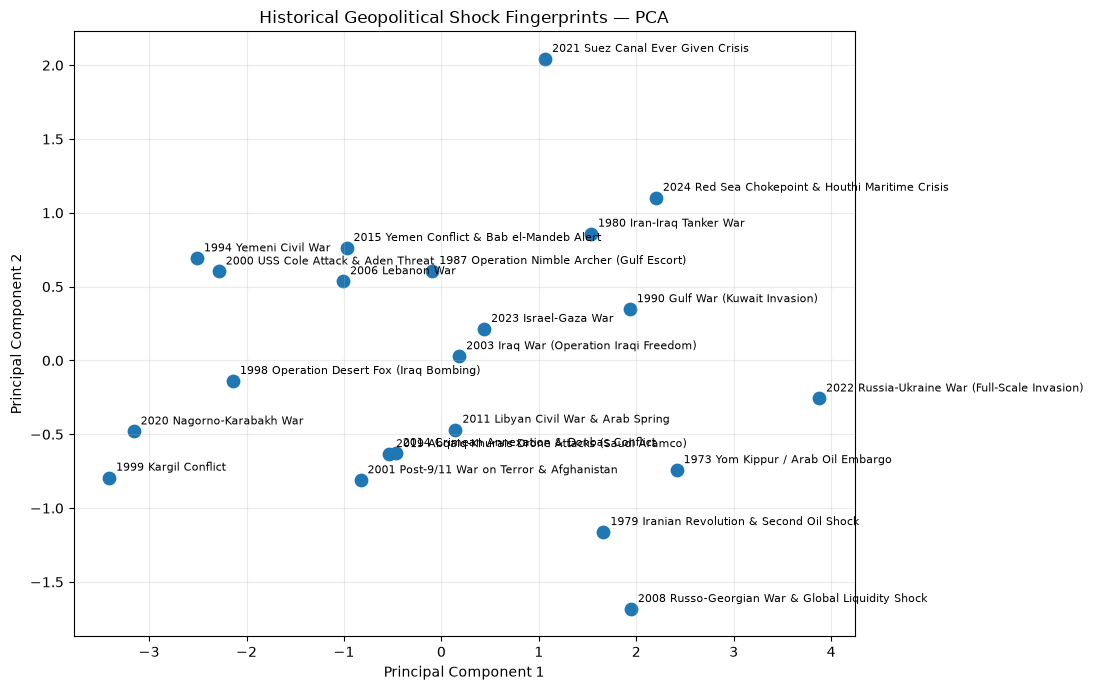

In [7]:
# Cell 7 — PCA visualization

plt.figure(figsize=(11, 7))

plt.scatter(df["PC1"], df["PC2"], s=80)

for _, row in df.iterrows():
    plt.annotate(
        row["conflict"],
        (row["PC1"], row["PC2"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Historical Geopolitical Shock Fingerprints — PCA")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Cell 8 — Select K for K-Means
Use silhouette score to compare candidate cluster counts.

This helps identify groups of historical conflicts with similar shock fingerprints.

In [8]:
# Cell 8 — Silhouette analysis for K selection

max_k = min(8, len(df) - 1)

if max_k < 2:
    raise ValueError("At least 3 historical observations are required for clustering.")

scores = {}

for k in range(2, max_k + 1):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

print("Silhouette scores:")
for k, score in scores.items():
    print(f"K={k}: {score:.4f}")

best_k = max(scores, key=scores.get)
print("Selected K:", best_k)

Silhouette scores:
K=2: 0.3699
K=3: 0.3362
K=4: 0.3421
K=5: 0.3038
K=6: 0.3450
K=7: 0.2973
K=8: 0.3287
Selected K: 2


### Cell 9 — K-Means historical conflict clustering
K-Means groups historical conflicts according to similarity in their shock fingerprints.

Cluster names such as “Energy Shock” should only be assigned after inspecting cluster characteristics; they are interpretations, not learned labels.

In [9]:
# Cell 9 — Fit K-Means

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(df["cluster"].value_counts().sort_index())

Cluster counts:
cluster
0     9
1    13
Name: count, dtype: int64


In [10]:
# Cell 10 — Inspect cluster characteristics

cluster_summary = df.groupby("cluster")[SHOCK_FEATURES].mean().round(3)

display(cluster_summary)

print("Interpret clusters using the feature means above.")
print("Do not assign a semantic cluster name before inspecting the actual values.")

,energy_shock,trade_disruption,shipping_disruption,commodity_shock,financial_stress
cluster,,,,,
0,78.778,75.111,76.778,71.778,74.556
1,52.769,46.846,51.538,43.000,53.846


Interpret clusters using the feature means above.
Do not assign a semantic cluster name before inspecting the actual values.


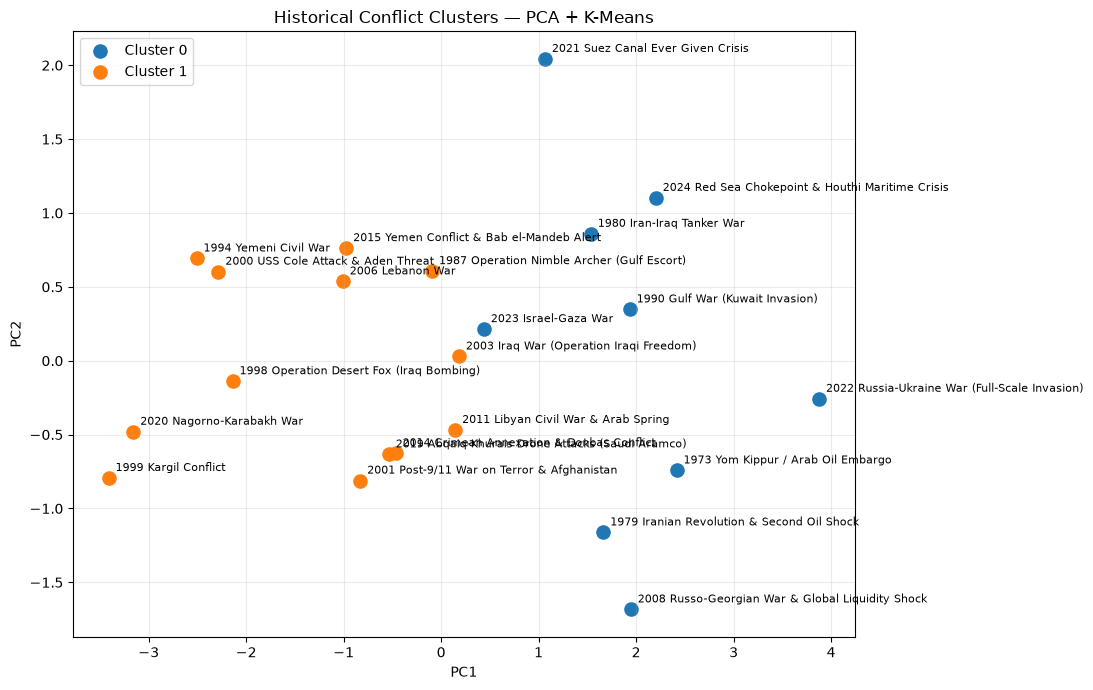

In [11]:
# Cell 11 — Cluster visualization in PCA space

plt.figure(figsize=(11, 7))

for cluster_id in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster_id]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=90,
        label=f"Cluster {cluster_id}"
    )

for _, row in df.iterrows():
    plt.annotate(
        row["conflict"],
        (row["PC1"], row["PC2"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Historical Conflict Clusters — PCA + K-Means")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Cell 12 — Historical impact evidence
This section connects each conflict fingerprint with observed historical economic indicators.

It does not train another prediction model.

The values must come from reliable historical datasets/sources.

In [12]:
# Cell 12 — Historical impact table

impact_table = df[
    [
        "conflict",
        "period",
        *SHOCK_FEATURES,
        *IMPACT_FEATURES,
        "cluster"
    ]
].sort_values(["cluster", "conflict"])

display(impact_table)

,conflict,period,energy_shock,trade_disruption,shipping_disruption,commodity_shock,financial_stress,inflation_change,gdp_growth_change,trade_growth_change,oil_price_change,cluster
0,1973 Yom Kippur / Arab Oil Embargo,1973-1974,96.0,68.0,72.0,78.0,84.0,8.4,-3.2,-5.6,285.0,0
1,1979 Iranian Revolution & Second Oil Shock,1979-1980,92.0,62.0,58.0,74.0,80.0,6.8,-2.4,-4.1,138.0,0
2,1980 Iran-Iraq Tanker War,1980-1988,86.0,70.0,88.0,60.0,65.0,4.2,-1.5,-3.8,45.0,0
3,1990 Gulf War (Kuwait Invasion),1990-1991,88.0,74.0,82.0,66.0,72.0,3.6,-1.8,-3.2,94.0,0
8,2008 Russo-Georgian War & Global Liquidity Shock,2008-2009,64.0,76.0,50.0,82.0,95.0,3.8,-4.2,-10.5,-52.0,0
13,2021 Suez Canal Ever Given Crisis,2021,45.0,88.0,95.0,62.0,55.0,1.7,-0.5,-4.2,12.0,0
14,2022 Russia-Ukraine War (Full-Scale Invasion),2022-2023,94.0,92.0,84.0,96.0,88.0,5.4,-2.6,-5.8,68.0,0
15,2023 Israel-Gaza War,2023,68.0,60.0,70.0,58.0,64.0,1.8,-0.7,-2.1,16.0,0
16,2024 Red Sea Chokepoint & Houthi Maritime Crisis,2024,76.0,86.0,92.0,70.0,68.0,2.6,-1.1,-4.6,22.0,0
20,1987 Operation Nimble Archer (Gulf Escort),1987,66.0,52.0,76.0,48.0,60.0,2.0,-0.5,-1.8,15.0,1


### Cell 13 — Then vs Now comparison
Add one current-event row using currently observed/measured indicators.

The current row is compared with historical clusters.

**Important:**
- This is a pattern comparison.
- It is NOT a claim that the current event will reproduce the historical loss.

In [13]:
# Cell 13 — Current event input

current_event = {
    "conflict": "CURRENT_EVENT",
    "period": "CURRENT",
    "energy_shock": 0.0,
    "trade_disruption": 0.0,
    "shipping_disruption": 0.0,
    "commodity_shock": 0.0,
    "financial_stress": 0.0
}

current_df = pd.DataFrame([current_event])

current_scaled = scaler.transform(current_df[SHOCK_FEATURES])

current_pca = pca.transform(current_scaled)

current_cluster = kmeans.predict(current_scaled)[0]

print("Current event cluster:", current_cluster)
print("Current event PCA coordinates:", current_pca[0])

Current event cluster: 1
Current event PCA coordinates: [-7.46744372  0.06070404]


In [14]:
# Cell 14 — Find historical observations in the same cluster

historical_cluster = df[df["cluster"] == current_cluster].copy()

print("Historical observations in the current event's cluster:")
display(
    historical_cluster[
        [
            "conflict",
            "period",
            *SHOCK_FEATURES,
            *IMPACT_FEATURES
        ]
    ].sort_values("conflict")
)

print("\nInterpretation:")
print(
    "The displayed historical observations share a similar shock-pattern cluster "
    "with the current event based on the supplied features."
)

Historical observations in the current event's cluster:


,conflict,period,energy_shock,trade_disruption,shipping_disruption,commodity_shock,financial_stress,inflation_change,gdp_growth_change,trade_growth_change,oil_price_change
20,1987 Operation Nimble Archer (Gulf Escort),1987,66.0,52.0,76.0,48.0,60.0,2.0,-0.5,-1.8,15.0
17,1994 Yemeni Civil War,1994,36.0,40.0,54.0,32.0,40.0,1.0,-0.3,-0.7,6.5
18,1998 Operation Desert Fox (Iraq Bombing),1998,48.0,45.0,40.0,35.0,46.0,0.9,-0.2,-0.5,11.0
4,1999 Kargil Conflict,1999,28.0,35.0,22.0,25.0,48.0,1.2,-0.4,-1.1,14.0
21,2000 USS Cole Attack & Aden Threat,2000,40.0,36.0,58.0,34.0,44.0,0.8,-0.2,-0.6,9.0
5,2001 Post-9/11 War on Terror & Afghanistan,2001-2002,42.0,55.0,48.0,38.0,78.0,1.4,-1.2,-2.8,-12.0
6,2003 Iraq War (Operation Iraqi Freedom),2003,72.0,58.0,64.0,54.0,62.0,2.1,-0.6,-1.5,32.0
7,2006 Lebanon War,2006,58.0,42.0,68.0,45.0,52.0,1.5,-0.3,-0.9,18.0
9,2011 Libyan Civil War & Arab Spring,2011,78.0,48.0,56.0,68.0,58.0,2.8,-0.8,-1.9,38.0
10,2014 Crimean Annexation & Donbas Conflict,2014-2015,52.0,64.0,44.0,50.0,66.0,1.9,-0.7,-2.2,-46.0



Interpretation:
The displayed historical observations share a similar shock-pattern cluster with the current event based on the supplied features.


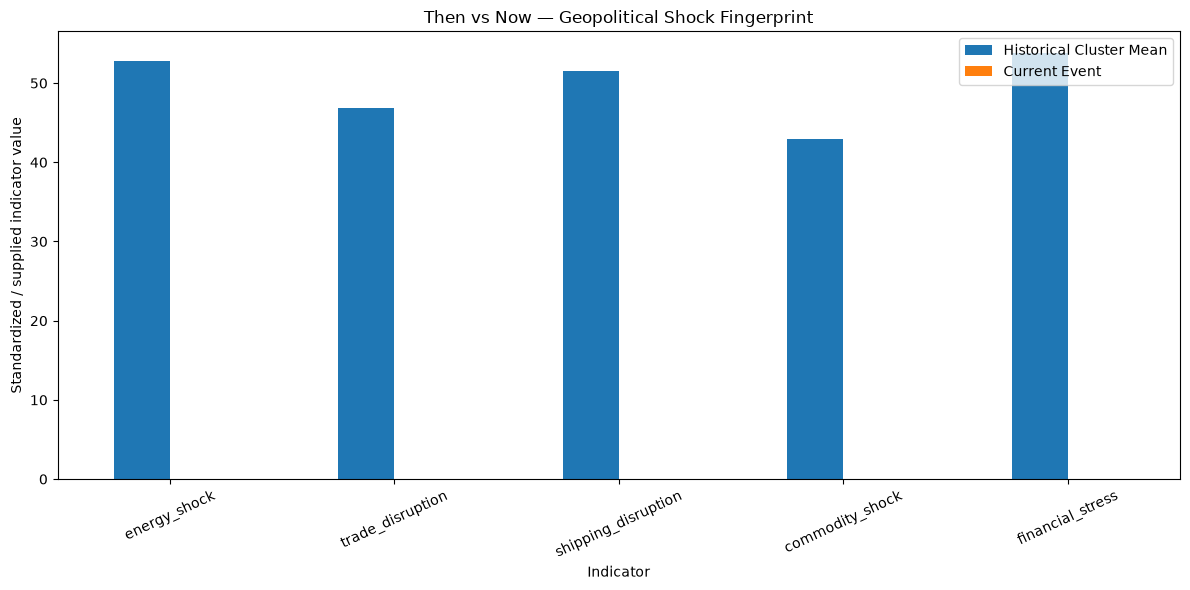

,Indicator,Historical Cluster Mean,Current Event
0,energy_shock,52.769,0.0
1,trade_disruption,46.846,0.0
2,shipping_disruption,51.538,0.0
3,commodity_shock,43.000,0.0
4,financial_stress,53.846,0.0


In [15]:
# Cell 15 — Then vs Now visualization

comparison_features = [
    "energy_shock",
    "trade_disruption",
    "shipping_disruption",
    "commodity_shock",
    "financial_stress"
]

current_values = current_df[comparison_features].iloc[0].values

historical_mean = historical_cluster[comparison_features].mean().values

comparison = pd.DataFrame({
    "Indicator": comparison_features,
    "Historical Cluster Mean": historical_mean,
    "Current Event": current_values
})

comparison.set_index("Indicator").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Then vs Now — Geopolitical Shock Fingerprint")
plt.ylabel("Standardized / supplied indicator value")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

display(comparison.round(3))

In [16]:
# Cell 16 — Save model artifacts and final output

import joblib

os.makedirs("models", exist_ok=True)

artifact = {
    "scaler": scaler,
    "pca": pca,
    "kmeans": kmeans,
    "shock_features": SHOCK_FEATURES,
    "impact_features": IMPACT_FEATURES,
    "selected_k": best_k
}

MODEL_PATH = "models/feature9_geopolitical_shock_fingerprint.joblib"

joblib.dump(artifact, MODEL_PATH)

print("Saved:", MODEL_PATH)

print("\nFINAL WORKFLOW")
print("Historical conflicts")
print("      ↓")
print("Shock indicators")
print("      ↓")
print("Standardization")
print("      ↓")
print("PCA")
print("      ↓")
print("K-Means")
print("      ↓")
print("Historical shock clusters")
print("      ↓")
print("Current event fingerprint")
print("      ↓")
print("Historical pattern comparison")
print("      ↓")
print("Then vs Now + potential impact channels")

Saved: models/feature9_geopolitical_shock_fingerprint.joblib

FINAL WORKFLOW
Historical conflicts
      ↓
Shock indicators
      ↓
Standardization
      ↓
PCA
      ↓
K-Means
      ↓
Historical shock clusters
      ↓
Current event fingerprint
      ↓
Historical pattern comparison
      ↓
Then vs Now + potential impact channels
